### Demonstration of ROI determination with stardist

In [1]:
import roiadjust as ra
import matplotlib.pyplot as plt
import numpy as np

##### First, determine a path to a folder containing at least one video or to a file itself.

In [2]:
# Auto-Reload of .py files
%reload_ext autoreload

# Load video either as a specified file or as a set of files in a directory
path_orig = "../caiman_motion/data/niels_video.avi" # path to video file or directory
video, video_path = ra.load_file(path_orig) # Load video

# FPS of the videos
video_fps = 5 

Lenght of video: 1500 Frames


##### Next, we create the mean intensity image of the video that is needed for the prediction of cells.

In [3]:
# Mean intensity of the video along axis 0 (frames)
video_mean = video.mean(axis=0)

##### The ROIs are next predicted using stardists pretrained model forfFluorescence stainings which takes 2D single channel pictures

In [4]:
# Predict ROIs using the video, with a probability threshold of "prob"
labels, polygons = ra.predict_neurons(video_mean, video_path, export=False, prob=0.7)

Found model '2D_versatile_fluo' for 'StarDist2D'.
Loading network weights from 'weights_best.h5'.
Loading thresholds from 'thresholds.json'.
Using default values: prob_thresh=0.479071, nms_thresh=0.3.


##### Next, the predicted ROIs are scanned for activity. Active ROIs are assigned to the positive_rois.

In [5]:
# Analyze the ROI traces using the video, with a prominence of "prom" and a cutoff of "cutoff"
positive_rois = ra.analyze_roi_traces(video, video_mean, video_path, labels, video_fps, show_graphs=False, 
                      prom=6, cutoff=0.2)

65 counted, positive ROIs


##### The positive ROIs can then be exported as ImageJ compatible format in .zip file.

In [ ]:
# Create the selected ROIs as ImageJ ROIs, with the option to export as .zip files
labels_positive, polygons_positive = ra.export_roi_selection(video_mean, video_path, labels, positive_rois)

Found model '2D_versatile_fluo' for 'StarDist2D'.
Loading network weights from 'weights_best.h5'.
Loading thresholds from 'thresholds.json'.
Using default values: prob_thresh=0.479071, nms_thresh=0.3.
Exported selected ROIs as ImageJ ROIs in: ../caiman_motion/data/niels_video_rois_filtered.zip


##### The whole pipeline can also be ran in one command.

Lenght of video: 1500 Frames
Found model '2D_versatile_fluo' for 'StarDist2D'.
Loading network weights from 'weights_best.h5'.
Loading thresholds from 'thresholds.json'.
Using default values: prob_thresh=0.479071, nms_thresh=0.3.
9 counted, positive ROIs
Found model '2D_versatile_fluo' for 'StarDist2D'.
Loading network weights from 'weights_best.h5'.
Loading thresholds from 'thresholds.json'.
Using default values: prob_thresh=0.479071, nms_thresh=0.3.
Selected ROIs: [2, 11, 21, 31, 41, 42, 59, 63, 76]


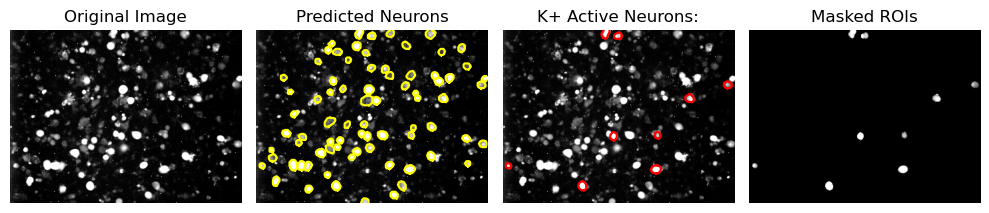

In [ ]:
# Or run the whole pipeline in one step, which will load the video, 
# predict ROIs, analyze the traces and export the selected ROIs as ImageJ ROIs in one step. 
# The parameters can be adjusted as needed.
# compare=True will show the predicted ROIs on the video mean and the selected ROIs 
# on the video mean next to each other for comparison.
ra.roi_pipeline(path="../caiman_motion/data/niels_video.avi", 
                export=False, prob=0.7, video_fps=5, 
                show_graphs=False, prom=10, cutoff=0.1, compare=True)

### Usage of ROIs with motion aligned videos

##### Again, we will first load the motion corrected video that is used for the prediction of ROIs. Then we will load the motion aligned video that should be analyzed with the ROIs.

In [ ]:
# Loading of the videos either as a specified file or as a set of files in a directory
path_corr_k= "../caiman_motion/export/m_corr_k.avi" # path to video file or directory
video_corr_k, video_path_corr_k = ra.load_file(path_corr_k) # Load video

path_al_spon = "../caiman_motion/export/m_aligned_spon.avi" 
video_al_spon, video_path_al_spon = ra.load_file(path_al_spon)

# define the FPS of the videos
video_fps = 5 

Lenght of video: 1500 Frames
Lenght of video: 2500 Frames


##### To run further analyses and to be able to plot the ROIs, we will need the mean intensity images.

In [ ]:
# Mean intensity of the video along axis 0 (frames)
video_corr_k_mean = video_corr_k.mean(axis=0)
video_al_spon_mean = video_al_spon.mean(axis=0)

##### Next we will run the prediction on the motion corrected video.

In [ ]:
# Predict ROIs using the video, with a probability threshold of "prob"
labels_corr_k, polygons_corr_k = ra.predict_neurons(video_corr_k_mean, video_path_corr_k, export=False, prob=0.7)

Found model '2D_versatile_fluo' for 'StarDist2D'.
Loading network weights from 'weights_best.h5'.
Loading thresholds from 'thresholds.json'.
Using default values: prob_thresh=0.479071, nms_thresh=0.3.


##### Now we can plot the predicted ROIs on the mean image of the original and aligned video to see how well they match up.

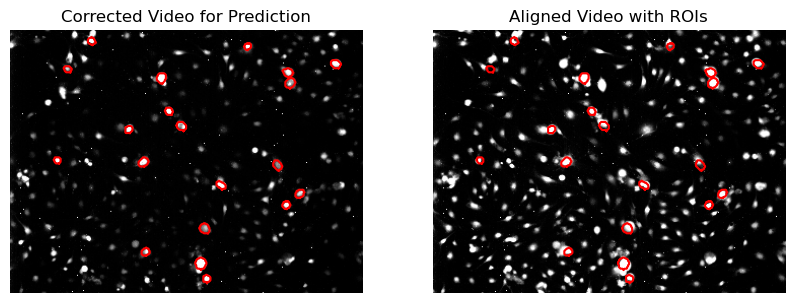

In [ ]:
#plot video_al_spon_mean and _k_mean next to each other
fig, axs = plt.subplots(1, 2, figsize=(10, 5))
ra.plot_roi_contours(video_al_spon_mean, labels_corr_k, roi_ids=None, color="red", ax=axs[1])
axs[1].set_title("Aligned Video with ROIs")
ra.plot_roi_contours(video_corr_k_mean, labels_corr_k, roi_ids=None, color="red", ax=axs[0])
axs[0].set_title("Corrected Video for Prediction")
plt.show()